In [37]:
import sys
sys.path.append("/project/src")

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from sksurv.metrics import integrated_brier_score, cumulative_dynamic_auc, brier_score
from sklearn.metrics import mean_squared_error
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from preprocessing import (
    split_features_target,
    low_missingness_complete_case_analysis,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)
from helpers import save_pic

import wandb
import joblib

In [39]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
    test_df_csv = "/content/drive/MyDrive/bachelor/nacc_test.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"
    test_df_csv = "./data/nacc_test.csv"

In [40]:
train_df = pd.read_csv(train_df_csv, delimiter=',')
test_df = pd.read_csv(test_df_csv, delimiter=',')

/tmp/ipykernel_3835/2510053026.py:2: DtypeWarning: Columns (4,8,27,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,190,193,195,201,203,205,207,209,211,217,219,223,227,233,235,237,245,370,372,394,405,545,576,601,672,689,706,760,763,805,813,814,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(test_df_csv, delimiter=',')


In [41]:
train_df.shape

(6499, 141)

In [42]:
train_X, train_y = split_features_target(train_df)

# Cross-Validation results

In [43]:
cox_pipeline = joblib.load("joblib-storage/cox_best_pipeline.joblib")
preprocessor = cox_pipeline.named_steps['preprocessor']
cox = cox_pipeline.named_steps['model']

In [44]:
cv_cindex = joblib.load("joblib-storage/cox_best_cv_cindex.joblib")
cv_cindex_std = joblib.load("joblib-storage/cox_best_cv_cindex_std.joblib")
print(f"Best CV C-index: {cv_cindex:.4f} ± {cv_cindex_std:.4f}")

Best CV C-index: 0.7660 ± 0.0191


# Evaluaition on test dataset

In [45]:
fitted_low_missingness_cols = preprocessor.get_low_missingness_cols()
test_preprepared_df = low_missingness_complete_case_analysis(test_df, low_missingness_columns=fitted_low_missingness_cols)
test_X_raw, test_y = split_features_target(test_preprepared_df)
test_X = preprocessor.transform(test_X_raw)

Complete-case analysis on low-missing columns
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [46]:
test_events = test_y[SURVIVAL_EVENT_COL].astype(bool)
test_times = test_y[SURVIVAL_TIME_COL]

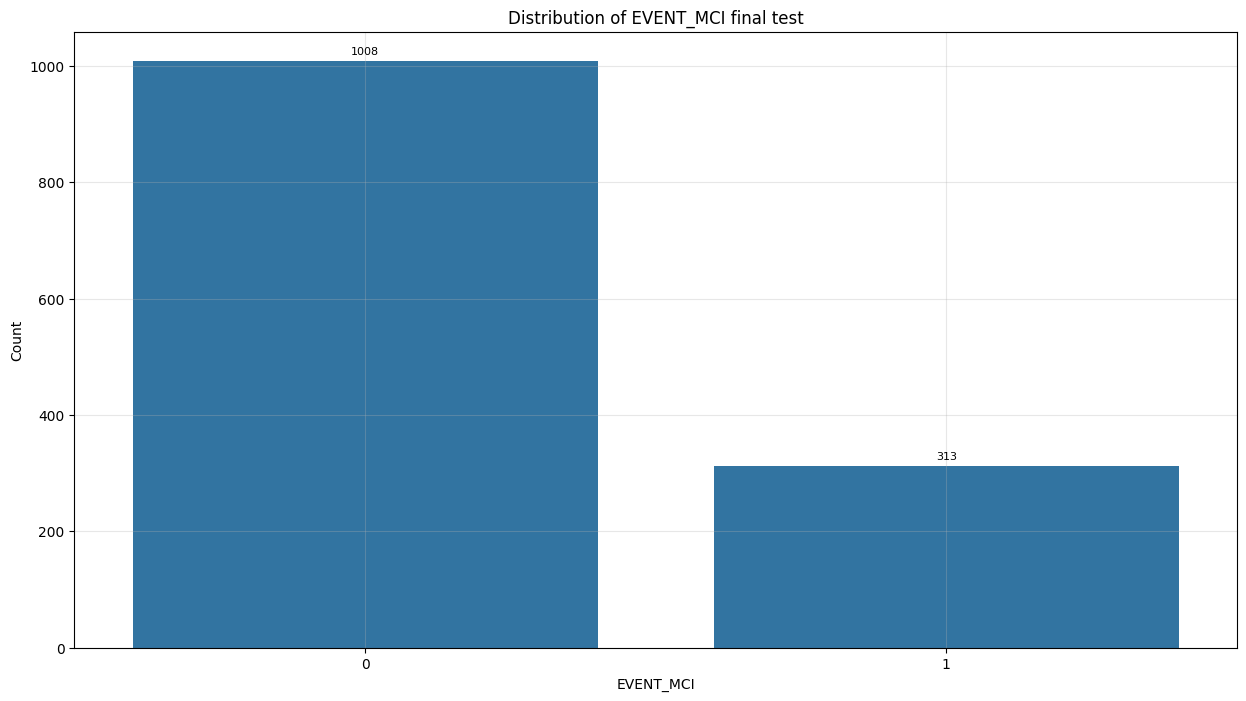

In [47]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=test_preprepared_df['EVENT_MCI'].value_counts().index, y=test_preprepared_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI final test')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
test_preprepared_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.763058
1    0.236942
Name: proportion, dtype: float64

In [49]:
test_X.shape

(1321, 294)

## Test c-index

In [50]:
cindex_test = cox.score(test_X, test_y)
print(f"Test C-index: {cindex_test:.4f}")

Test C-index: 0.7571


## Test IBS

In [51]:
event_min_time = test_times[test_events].min()
event_max_time = test_times[test_events].max()
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

Event times range from 0.85 to 18.17 years


In [52]:
times_ibs = np.linspace(event_min_time, event_max_time, 100)

In [53]:
surv_probs_by_time = cox.predict_survival_function(test_X, times=times_ibs)
surv_probs_by_time.shape

(100, 1321)

In [54]:
surv_matrix = surv_probs_by_time.values.T
surv_matrix.shape

(1321, 100)

In [55]:
# IBS expect matric in format (n_patients, n_timepoints), so we need to transpose the matrix
T_surv_matrix = surv_probs_by_time.values.T

ibs = integrated_brier_score(train_y, test_y, T_surv_matrix, times_ibs)
print(f"Integrated Brier Score: {ibs:.4f}")

# wandb.log({"eval/integrated_brier_score": ibs})

Integrated Brier Score: 0.1904


## Test KM and Survival curve

In [56]:
kmf = KaplanMeierFitter()
kmf.fit(test_times, event_observed=test_events)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1321 total observations, 1008 right-censored observations>

In [57]:
predicted_surv = cox.predict_survival_function(test_X).mean(axis=1)
predicted_surv.head(5)

0.145    0.999682
0.468    0.999364
0.652    0.999364
0.690    0.998728
0.747    0.998410
dtype: float64

In [58]:
test_times_min = test_times.min()
test_times_max = test_times.max()
times_to_plot = np.linspace(test_times_min, test_times_max, 100)

In [59]:
brier_times = np.arange(int(test_times_min)+1, int(test_times_max)+1)
brier_score_df = cox.predict_survival_function(test_X, times=brier_times)
brier_scores_T = brier_score_df.values.T

_, brier_scores = brier_score(train_y, test_y, brier_scores_T, brier_times)
brier_scores

array([0.01094734, 0.07105634, 0.09828925, 0.1202027 , 0.13594819,
       0.14900603, 0.15647641, 0.1616567 , 0.16838335, 0.18340046,
       0.21023754, 0.2221452 , 0.2369177 , 0.24224569, 0.26567342,
       0.28145177, 0.2828    , 0.29629594])

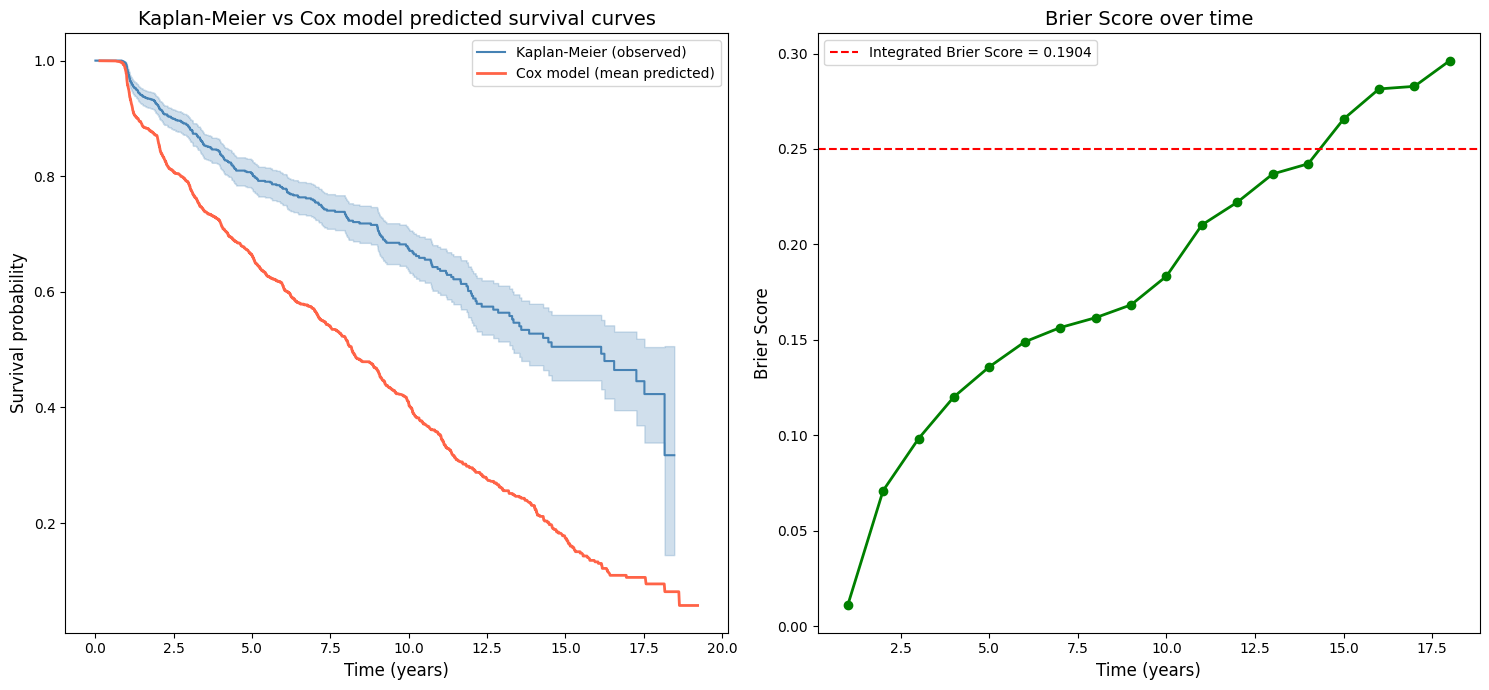

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
kmf.plot_survival_function(ax=ax[0], label="Kaplan-Meier (observed)", color="steelblue")
ax[0].plot(predicted_surv.index, predicted_surv.values, color="tomato", linewidth=2, label="Cox model (mean predicted)")
ax[0].set_xlabel("Time (years)", fontsize=12)
ax[0].set_ylabel("Survival probability", fontsize=12)
ax[0].set_title("Kaplan-Meier vs Cox model predicted survival curves", fontsize=14)
ax[0].legend()  

ax[1].plot(brier_times, brier_scores, color="green", marker="o", linewidth=2)
ax[1].axhline(0.25, color="red", linestyle="--", label=f"Integrated Brier Score = {ibs:.4f}")
ax[1].set_xlabel("Time (years)", fontsize=12)
ax[1].set_ylabel("Brier Score", fontsize=12)
ax[1].set_title("Brier Score over time", fontsize=14)
ax[1].legend()
plt.tight_layout()
plt.show()

In [61]:
times = np.linspace(test_times_min, test_times_max, 100)
pred_surv = cox.predict_survival_function(test_X, times=times).values.T
predicted_mean = np.mean(pred_surv, axis=0)
kmf_surv_scores = kmf.survival_function_at_times(times).values

abs_errors = np.abs(kmf_surv_scores - predicted_mean)

rmse      = np.sqrt(mean_squared_error(kmf_surv_scores, predicted_mean))
median_ae = np.median(abs_errors)
mean_ae   = np.mean(abs_errors)

print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

RMSE:             0.2514
Median Abs Error: 0.2477
Mean Abs Error:   0.2313


## Risk groups

In [62]:
risk_scores = cox.predict_partial_hazard(test_X).values

risk_df = pd.DataFrame({
  "scores": risk_scores,
  "event": test_events,
  "duration": test_times
})
risk_df.head()

,scores,event,duration
0,1.401248,False,2.086
1,0.488200,False,14.541
2,0.848922,False,4.036
3,1.606801,True,3.211
4,0.252425,False,10.059


In [63]:
stable_patients = risk_df[risk_df["event"] == False].copy()
converted_patients = risk_df[risk_df["event"] == True].copy()
stable_patients_scores = stable_patients["scores"]
converted_patients_scores = converted_patients["scores"]

print(f"cMCI risk scores: min={stable_patients_scores.min():.2f}, max={stable_patients_scores.max():.2f}, median={stable_patients_scores.median():.2f}")
print(f"pMCI risk scores: min={converted_patients_scores.min():.2f}, max={converted_patients_scores.max():.2f}, median={converted_patients_scores.median():.2f}")

cMCI risk scores: min=0.22, max=12.34, median=0.91
pMCI risk scores: min=0.28, max=12.94, median=1.30


In [64]:
NUMBER_OF_BINS = 80

In [65]:
bin_edges = np.linspace(converted_patients["scores"].min(), converted_patients["scores"].max(), NUMBER_OF_BINS + 1)
low_medium_cutoff = np.percentile(converted_patients["scores"], 33.333)
medium_high_cutoff = np.percentile(converted_patients["scores"], 66.667)

low_risk = converted_patients[converted_patients["scores"] <= low_medium_cutoff]['scores'].values
medium_risk = converted_patients[(converted_patients["scores"] > low_medium_cutoff) & ( converted_patients["scores"] <= medium_high_cutoff)]['scores'].values
high_risk = converted_patients[converted_patients["scores"] > medium_high_cutoff]['scores'].values

print(f"Low risk group:    {len(low_risk)} patients")
print(f"Medium risk group: {len(medium_risk)} patients")
print(f"High risk group:   {len(high_risk)} patients")

Low risk group:    104 patients
Medium risk group: 105 patients
High risk group:   104 patients


In [66]:
LOW_RISK_GROUP_INDICATOR = 0
MEDIUM_RISK_GROUP_INDICATOR = 1
HIGH_RISK_GROUP_INDICATOR = 2

def assign_patient_to_risk_group(score, low_cutoff, high_cutoff):
    if score <= low_cutoff:
        return LOW_RISK_GROUP_INDICATOR
    elif score <= high_cutoff:
        return MEDIUM_RISK_GROUP_INDICATOR
    else:
        return HIGH_RISK_GROUP_INDICATOR

In [67]:
converted_patients["risk_group"] = converted_patients["scores"].apply(lambda s: assign_patient_to_risk_group(s, low_medium_cutoff, medium_high_cutoff))
converted_patients.head()

,scores,event,duration,risk_group
3,1.606801,True,3.211,1
6,1.146712,True,8.030,1
8,2.547264,True,1.916,2
14,3.870185,True,1.793,2
15,8.707221,True,2.012,2


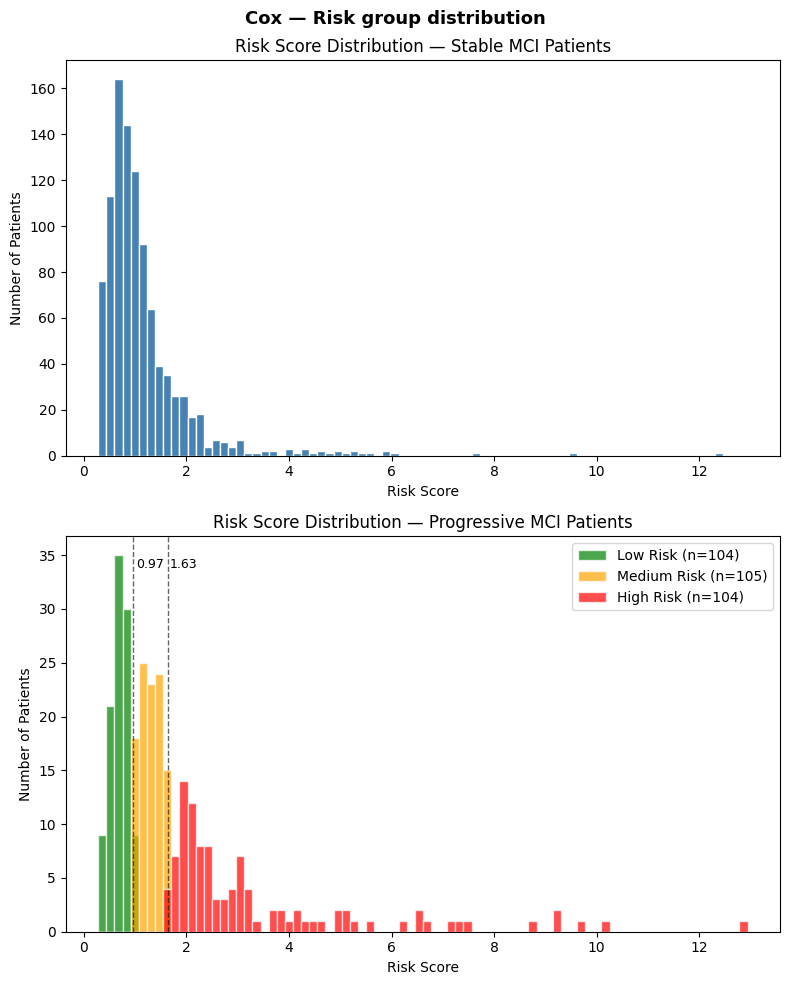

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].hist(stable_patients_scores, bins=bin_edges, color="steelblue", edgecolor="white")
axes[0].set_title("Risk Score Distribution — Stable MCI Patients", fontsize=12)
axes[0].set_xlabel("Risk Score", fontsize=10)
axes[0].set_ylabel("Number of Patients", fontsize=10)

axes[1].hist(low_risk, bins=bin_edges, color="green", label=f"Low Risk (n={len(low_risk)})", edgecolor="white", alpha=0.7)
axes[1].hist(medium_risk, bins=bin_edges, color="orange", label=f"Medium Risk (n={len(medium_risk)})", edgecolor="white", alpha=0.7)
axes[1].hist(high_risk, bins=bin_edges, color="red", label=f"High Risk (n={len(high_risk)})", edgecolor="white", alpha=0.7)
axes[1].legend(fontsize=10)
axes[1].set_title("Risk Score Distribution — Progressive MCI Patients", fontsize=12)
axes[1].set_xlabel("Risk Score", fontsize=10)
axes[1].set_ylabel("Number of Patients", fontsize=10)

axes[1].axvline(low_medium_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[1].axvline(medium_high_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
ymax = axes[1].get_ylim()[1]
axes[1].text(low_medium_cutoff + 0.05, ymax * 0.92, f'{low_medium_cutoff:.2f}', fontsize=9, color='black')
axes[1].text(medium_high_cutoff + 0.05, ymax * 0.92, f'{medium_high_cutoff:.2f}', fontsize=9, color='black')

plt.suptitle("Cox — Risk group distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
save_pic(plt, "risk_groups_distribution.png")
plt.show()

### Analyse significance of group separation

In [69]:
overall = multivariate_logrank_test(
    converted_patients['duration'],
    converted_patients['risk_group'],
    converted_patients['event']
)
overall.print_summary()
print(f"Overall log-rank p-value: {overall.p_value:.20f}")

pairwise = pairwise_logrank_test(
    converted_patients['duration'],
    converted_patients['risk_group'],
    converted_patients['event']
)
pairwise.print_summary()

Overall log-rank p-value: 0.00000000000000032227


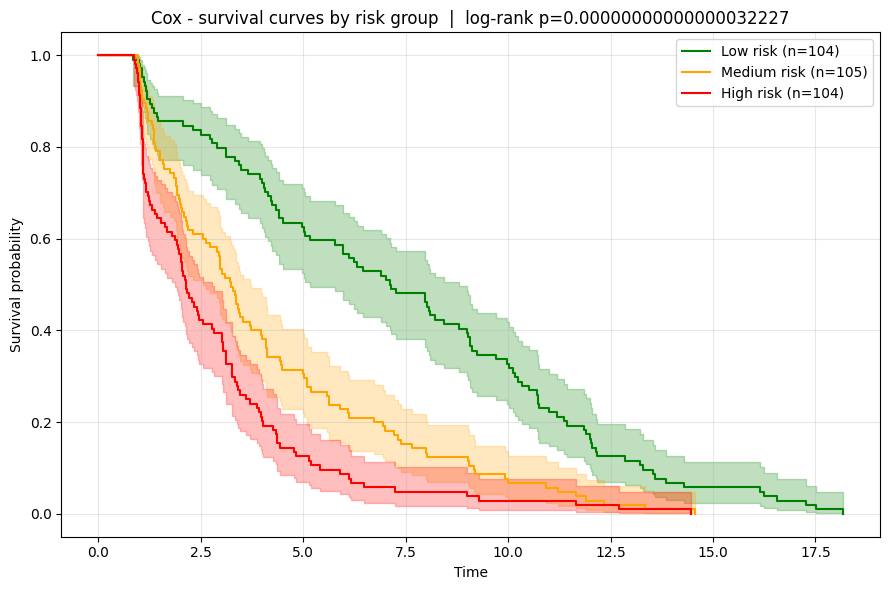

In [70]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    LOW_RISK_GROUP_INDICATOR: {"color": 'green', "name": "Low risk"},
    MEDIUM_RISK_GROUP_INDICATOR: {"color": 'orange', "name": "Medium risk"},
    HIGH_RISK_GROUP_INDICATOR: {"color": 'red', "name": "High risk"}
}
kmf = KaplanMeierFitter()

for group in [LOW_RISK_GROUP_INDICATOR, MEDIUM_RISK_GROUP_INDICATOR, HIGH_RISK_GROUP_INDICATOR]:
    mask = converted_patients['risk_group'] == group
    kmf.fit(
        converted_patients.loc[mask, 'duration'],
        converted_patients.loc[mask, 'event'],
        label=f'{colors[group]["name"]} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[group]["color"])

ax.set_xlabel("Time")
ax.set_ylabel("Survival probability")
ax.set_title(f"Cox - survival curves by risk group  |  log-rank p={overall.p_value:.20f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Time dependent ROC-AUC

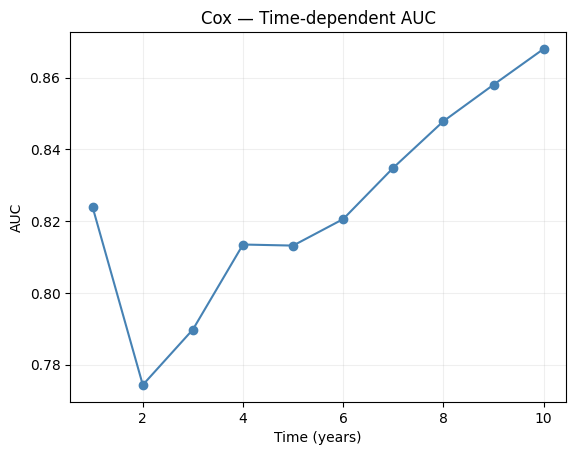

AUC at 1 year(s): 0.8238
AUC at 2 year(s): 0.7743
AUC at 3 year(s): 0.7898
AUC at 4 year(s): 0.8135
AUC at 5 year(s): 0.8132
AUC at 6 year(s): 0.8206
AUC at 7 year(s): 0.8349
AUC at 8 year(s): 0.8478
AUC at 9 year(s): 0.8580
AUC at 10 year(s): 0.8680
Mean AUC:          0.8169


In [71]:
times_roc   = np.arange(1, 11)
risk_scores = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("Cox — Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

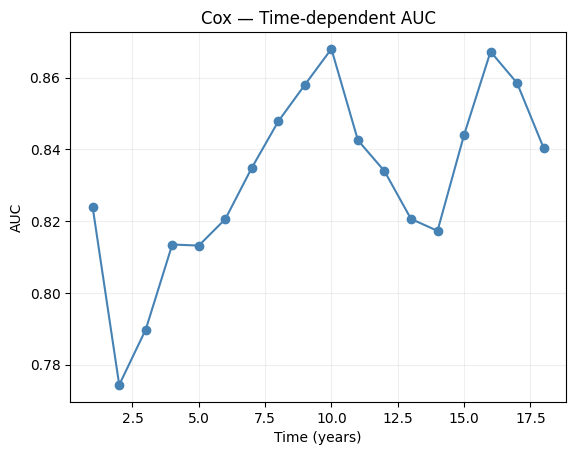

AUC at 1 year(s): 0.8238
AUC at 2 year(s): 0.7743
AUC at 3 year(s): 0.7898
AUC at 4 year(s): 0.8135
AUC at 5 year(s): 0.8132
AUC at 6 year(s): 0.8206
AUC at 7 year(s): 0.8349
AUC at 8 year(s): 0.8478
AUC at 9 year(s): 0.8580
AUC at 10 year(s): 0.8680
AUC at 11 year(s): 0.8425
AUC at 12 year(s): 0.8339
AUC at 13 year(s): 0.8206
AUC at 14 year(s): 0.8173
AUC at 15 year(s): 0.8440
AUC at 16 year(s): 0.8672
AUC at 17 year(s): 0.8585
AUC at 18 year(s): 0.8404
Mean AUC:          0.8255


In [72]:
times_roc   = np.arange(int(test_times_min)+1, int(test_times_max) + 1)
risk_scores = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("Cox — Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

Using timepoints: [1, 3, 5]
AUC scores: [0.8237904  0.78977419 0.81316502]


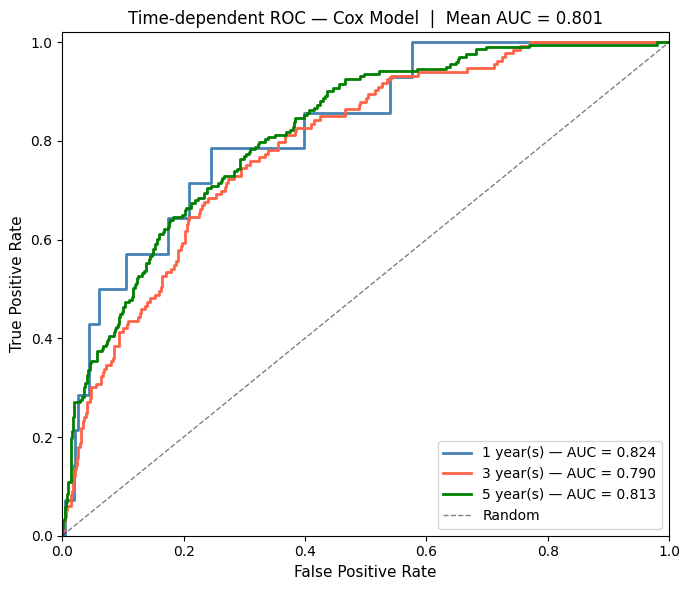

In [ ]:
from sklearn.metrics import roc_curve
from sksurv.metrics import cumulative_dynamic_auc
import matplotlib.pyplot as plt

times_roc = [1, 3, 5]
print(f"Using timepoints: {times_roc}")

risk_scores  = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(
    train_y, test_y, risk_scores, times_roc
)
print(f"AUC scores: {auc_scores}")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['steelblue', 'tomato', 'green']

for t, auc_val, color in zip(times_roc, auc_scores, colors):
    known_mask    = (test_y[SURVIVAL_EVENT_COL].astype(bool)) | (test_y[SURVIVAL_TIME_COL] >= t)
    y_true_binary = ((test_y[SURVIVAL_EVENT_COL].astype(bool)) &(test_y[SURVIVAL_TIME_COL] <= t))[known_mask].astype(int)
    risk_known    = risk_scores[known_mask]

    fpr, tpr, _   = roc_curve(y_true_binary, risk_known)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{t} year(s) — AUC = {auc_val:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"Time-dependent ROC — Cox Model  |  Mean AUC = {mean_auc:.3f}",
             fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
save_pic(plt, "roc_auc_curves.png")
plt.show()

In [ ]:
wandb.log({"eval/roc_auc_curves": wandb.Image("roc_auc_curves.png")})

In [ ]:
# from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve

# times_eval = [1, 3, 5]
# print(f"Using timepoints: {times_eval}")
# risk_scores = cox.predict_partial_hazard(test_X).values
# results = []

# for t in times_eval:
#     # exclude patients with unknown outcome at this timepoint
#     known_mask    = (test_y[SURVIVAL_EVENT_COL].astype(bool)) | (test_y[SURVIVAL_TIME_COL] >= t)
#     y_true        = ((test_y[SURVIVAL_EVENT_COL].astype(bool)) & (test_y[SURVIVAL_TIME_COL] <= t))[known_mask].astype(int)
#     risk_known    = risk_scores[known_mask]

#     # find optimal threshold via Youden index
#     fpr, tpr, thresholds = roc_curve(y_true, risk_known)
#     youden_idx            = np.argmax(tpr - fpr)
#     optimal_threshold     = thresholds[youden_idx]
#     y_pred = (risk_known >= optimal_threshold).astype(int)

#     # metrics
#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#     accuracy    = accuracy_score(y_true, y_pred)
#     sensitivity = tp / (tp + fn)
#     specificity = tn / (tn + fp)

#     results.append({
#         'timepoint':         t,
#         'n_patients':        known_mask.sum(),
#         'n_events':          y_true.sum(),
#         'threshold':         round(optimal_threshold, 3),
#         'accuracy':          round(accuracy,    3),
#         'sensitivity':       round(sensitivity, 3),
#         'specificity':       round(specificity, 3),
#     })

#     print(f"\n{'='*45}")
#     print(f"Timepoint: {t} year(s)")
#     print(f"Patients with known outcome: {known_mask.sum()}")
#     print(f"Events (converted):          {y_true.sum()}")
#     print(f"Optimal threshold:           {optimal_threshold:.3f}")
#     print(f"Accuracy:                    {accuracy:.3f}")
#     print(f"Sensitivity:                 {sensitivity:.3f}")
#     print(f"Specificity:                 {specificity:.3f}")

Using timepoints: [1, 3, 5]

Timepoint: 1 year(s)
Patients with known outcome: 1284
Events (converted):          14
Optimal threshold:           1.441
Accuracy:                    0.755
Sensitivity:                 0.786
Specificity:                 0.755

Timepoint: 3 year(s)
Patients with known outcome: 995
Events (converted):          133
Optimal threshold:           1.146
Accuracy:                    0.701
Sensitivity:                 0.759
Specificity:                 0.691

Timepoint: 5 year(s)
Patients with known outcome: 799
Events (converted):          203
Optimal threshold:           1.014
Accuracy:                    0.715
Sensitivity:                 0.783
Specificity:                 0.691
